In [95]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                              accuracy_score, precision_score, recall_score, f1_score,mean_absolute_error,mean_squared_error)
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score
import joblib

In [96]:
#task1
#subtask1.1
data = pd.read_csv('/content/Public_Bus_Operations_Multi_Target.csv')
print('Dataset shape:', data.shape)
data.head()

Dataset shape: (10000, 11)


,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
0,TRIP201396,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84
1,TRIP203651,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26
2,TRIP200153,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64
3,TRIP209009,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70
4,TRIP204405,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37


The dataset has 10000 rows and 11 columns. Each row represents one
historical bus trip and each column represents one feature including the 2 we want to predict delay_level and trip_duration_minutes



In [97]:
#subtask1.2
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  10000 non-null  object 
 1   weather_condition        9742 non-null   object 
 2   bus_type                 9798 non-null   object 
 3   traffic_level            10000 non-null  object 
 4   route_distance_km        9849 non-null   float64
 5   stops_count              10000 non-null  int64  
 6   passenger_count          9818 non-null   float64
 7   driver_experience_years  9777 non-null   float64
 8   scheduled_start_hour     10000 non-null  int64  
 9   delay_level              10000 non-null  object 
 10  trip_duration_minutes    10000 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 859.5+ KB


In [98]:
data.describe()


,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,trip_duration_minutes
count,9849.000000,10000.000000,9818.000000,9777.000000,10000.000000,10000.000000
mean,10.622125,11.227500,30.434101,6.151693,13.957900,60.837522
std,5.489059,6.064505,12.695660,3.999918,5.501323,33.956659
min,2.000000,3.000000,3.000000,0.200000,5.000000,12.000000
25%,6.530000,7.000000,21.000000,3.140000,9.000000,36.660000
50%,9.600000,10.000000,31.000000,5.280000,14.000000,52.335000
75%,13.660000,15.000000,39.000000,8.270000,19.000000,76.490000
max,32.000000,37.000000,65.000000,18.000000,23.000000,180.000000


In [99]:
data.describe(include='object')   # categorical columns

,trip_id,weather_condition,bus_type,traffic_level,delay_level
count,10000,9742,9798,10000,10000
unique,9850,4,3,4,3
top,TRIP201217,Clear,Standard,Moderate,On Time
freq,2,5305,5594,3785,3334


In [100]:
missing_count = data.isna().sum()
missing_pct = (data.isna().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

                         Missing Count  Missing %
weather_condition                  258       2.58
bus_type                           202       2.02
route_distance_km                  151       1.51
passenger_count                    182       1.82
driver_experience_years            223       2.23


In [101]:
print('Exact duplicate rows:', data.duplicated().sum())

Exact duplicate rows: 150



- Columns with missing values:

1.   weather_condition

1.   bus_type

1.   route_distance_km

1.   passenger_count
2.   driver_experience_years


                         
   — They will impute
     with most-frequent or median since dropping rows would lose usable trips.
- 150 exact duplicate rows found these will be dropped before modelling
  to avoid double-counting the same trip and biasing both targets.

In [102]:
#subtask1.3
target_counts = data['delay_level'].value_counts()
target_pct = data['delay_level'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(1)}))

                Count  Percentage
delay_level                      
On Time          3334        33.3
Moderate Delay   3333        33.3
Severe Delay     3333        33.3


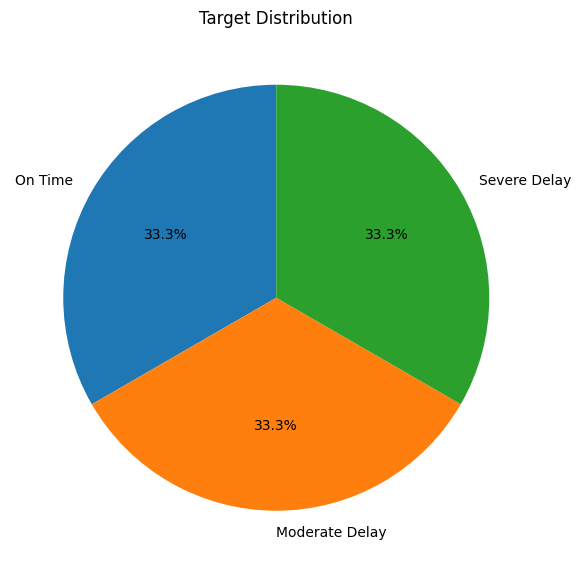

In [103]:
plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Target Distribution')
plt.tight_layout()
plt.show()

The three delay classes are balanced then accuracy is a reasonably
safe metric while we will also use f1 scores

In [104]:
#subtask1.4
print(data['trip_duration_minutes'].describe())
print('Skew:', data['trip_duration_minutes'].skew())

Q1 = data['trip_duration_minutes'].quantile(0.25)
Q3 = data['trip_duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['trip_duration_minutes'] < Q1 - 1.5*IQR) |
                (data['trip_duration_minutes'] > Q3 + 1.5*IQR)]
print('Outlier trips (IQR rule):', len(outliers))

count    10000.000000
mean        60.837522
std         33.956659
min         12.000000
25%         36.660000
50%         52.335000
75%         76.490000
max        180.000000
Name: trip_duration_minutes, dtype: float64
Skew: 1.3093470523101352
Outlier trips (IQR rule): 402


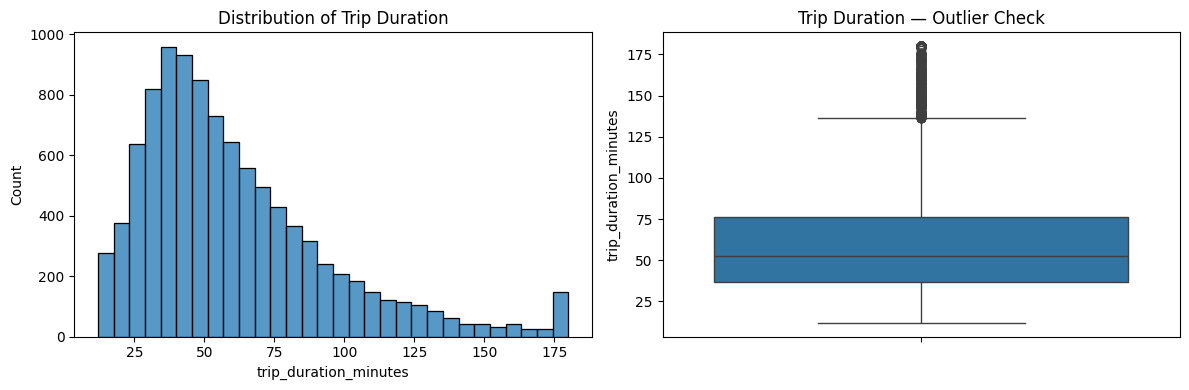

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data['trip_duration_minutes'].dropna(), bins=30, edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of Trip Duration')
sns.boxplot(y=data['trip_duration_minutes'], ax=axes[1])
axes[1].set_title('Trip Duration — Outlier Check')
plt.tight_layout()
plt.show()

- **Centre:** median trip duration is 52.3 minutes (mean is a bit higher at
  60.8, pulled up by the long tail).
- **Spread:** IQR runs from 36.7 to 76.5 minutes (IQR = 39.8), so the
  middle half of trips fall in a fairly wide ~40-minute band. Range overall
  is 12 to 180 minutes.
- **Shape:** skew = 1.31 clearly right-skewed. Most trips cluster

- **Unusual values:** 402 trips flagged as outliers by the IQR rule,
  . There's also a spike right
  at the 175–180 bin in the histogram that looks less like natural
  variation  
- **Why it matters for modelling:** the right skew and the outlier tail
  mean a model trained on raw MAE/MSE could be disproportionately pulled
  by these long trips.

# Question :
# Which numeric features move together with delay severity or trip duration?

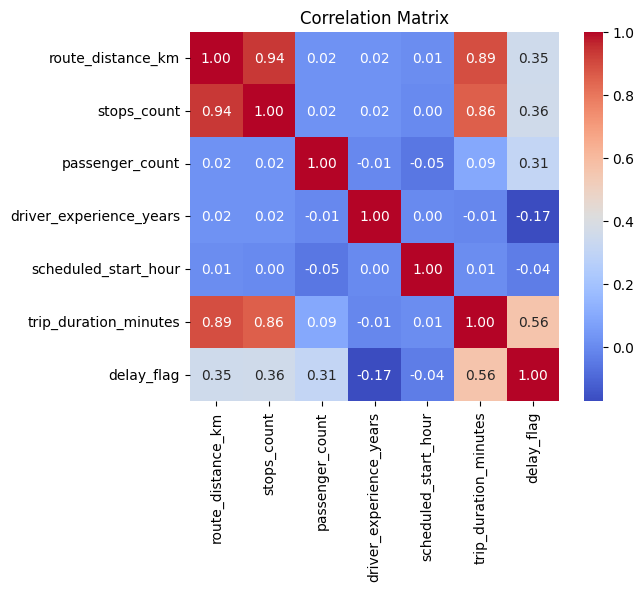

In [106]:
#subtask1.5
data['delay_flag'] = data['delay_level'].map({
    'On Time': 0,
    'Moderate Delay': 1,
    'Severe Delay': 2
})

numeric_for_correlation = [
    'route_distance_km', 'stops_count',
    'passenger_count', 'driver_experience_years',
    'scheduled_start_hour', 'trip_duration_minutes', 'delay_flag'
]

correlation_matrix = data[numeric_for_correlation].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', square=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Observation:** route_distance_km and stops_count are almost the same
thing (0.94) longer routes just have more stops. Both are strongly linked
to trip_duration_minutes (0.89 and 0.86), which makes sense where longer
routes with more stops take more time. trip_duration_minutes also has a
link to delay_flag (0.56) so longer trips tend to be more delayed.
Everything else barely correlates with anything (all close to 0).

**Conclusion:** distance, stops, and duration mean nearly the same so we don't
need all three in the model Delay
isn't strongly tied to just one number, so it's probably caused by a mix of
things (like duration plus weather/traffic), not one single factor.

#Question:
#Does trip duration differ across delay levels?

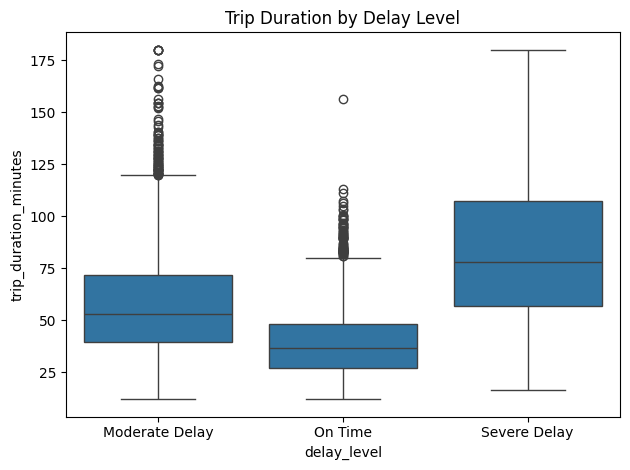

In [107]:
sns.boxplot(x="delay_level", y='trip_duration_minutes', data=data)
plt.title('Trip Duration by Delay Level')
plt.tight_layout()
plt.show()

**Observation:** On-time trips have the shortest durationmoderate delays are longerand severe delays are longest with the widest spread too.

**Conclusion:** duration and delay level rise together so duration is a
useful signal for delay but since they're this closely linked,
trip_duration_minutes should be left out of the classification features
and delay_level out of the regression features to avoid one target
leaking into the other.

# Question:
#Does traffic affect the chance of a severe delay?



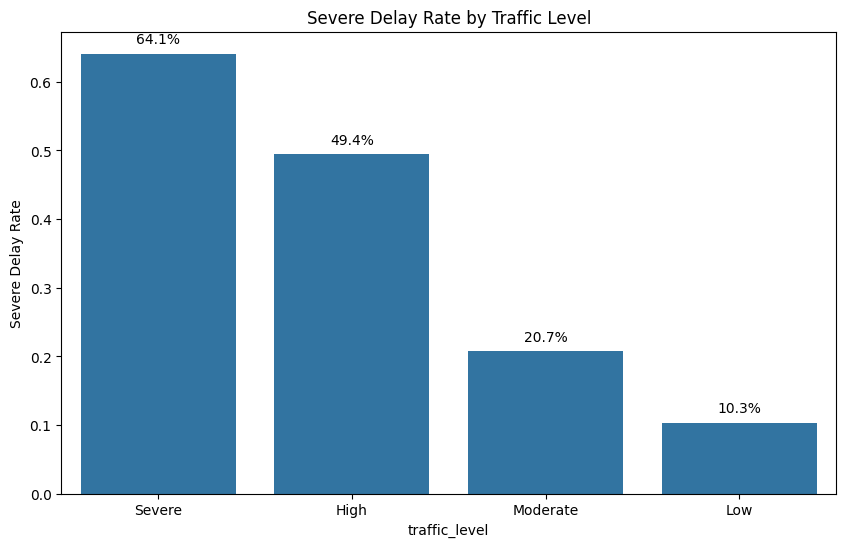

In [108]:
data['severe_delay_flag'] = (data['delay_level'] == 'Severe Delay').astype(int)

def plot_delay_rate_by(data, column, ascending=False):
    plot_data = (
        data.groupby(column, dropna=False)['severe_delay_flag']
        .mean()
        .sort_values(ascending=ascending)
        .reset_index()
    ).dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=plot_data, x=column, y='severe_delay_flag',
                order=plot_data[column], errorbar=None, ax=ax)
    for bar in ax.patches:
        rate = bar.get_height()
        ax.annotate(f'{rate:.1%}',
                     xy=(bar.get_x() + bar.get_width() / 2, rate),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', va='bottom')
    label = column.replace('_', ' ').title()
    ax.set_title(f'Severe Delay Rate by Traffic Level')
    ax.set_ylabel('Severe Delay Rate')
    plt.show()
plot_delay_rate_by(data, 'traffic_level')

**Observation:** severe delay rate climbs steadily with traffic which makes sense where it is 10.3% at
Low traffic, 20.7% at Moderate, 49.4% at High, and 64.1% at Severe traffic.

**Conclusion:** traffic level is a strong, clearly ordered predictor of
severe delays, and should be kept as an important feature in the
classification model.

In [109]:
#task2
#subtask2.1
clean_data = (
    data
    .drop_duplicates()
    .drop(columns=['trip_id'])
    .reset_index(drop=True)
)


X = clean_data.drop(columns=['delay_level', 'trip_duration_minutes','severe_delay_flag','delay_flag'])
y_class = clean_data['delay_level']
y_reg = clean_data['trip_duration_minutes']
print('X shape:', X.shape)
print('X columns:', list(X.columns))
print('y_class shape:', y_class.shape)
print('y_reg shape:', y_reg.shape)

X shape: (9850, 8)
X columns: ['weather_condition', 'bus_type', 'traffic_level', 'route_distance_km', 'stops_count', 'passenger_count', 'driver_experience_years', 'scheduled_start_hour']
y_class shape: (9850,)
y_reg shape: (9850,)


In [110]:
#subtask2.2
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg,
    test_size=0.20, random_state=42, stratify=y_class
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

Train size: 7880 | Test size: 1970


Splitting strategy: single 80/20 split, stratified on delay_level so
the delay classes keep their proportions in train/test. The same split
indices back both targets, so Task 3 and Task 4 are compared on identical
data. Test set is locked until final evaluation while the trip_id was deleted to prevent leakage while trip_duration_minutes was removed from the classification features and delay_level from the regression features to avoid leakage as well

In [111]:
#subtask2.3
nominal_features = ['weather_condition', 'bus_type']
ordinal_features = ['traffic_level']
numerical_features = ['route_distance_km', 'stops_count', 'passenger_count',
                       'driver_experience_years', 'scheduled_start_hour',]

- Nominal (weather_condition, bus_type): categories with no order
- Ordinal (traffic_level): Low < Moderate < High < Severe (ordered)
- Numerical (route_distance_km, stops_count, passenger_count,
  driver_experience_years, scheduled_start_hour): continuous/count

In [112]:
#subtask2.4
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        ['Low', 'Moderate', 'High', 'Severe'],
    ])),
])

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', nominal_pipeline, nominal_features),
        ('ordinal', ordinal_pipeline, ordinal_features),
        ('numerical', numerical_pipeline, numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

In [114]:
#task3
#subtask3.1
model_search_space = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'parameters': {
            'model__C': [0.1, 1, 10],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'SVM': {
        'model': SVC(random_state=42),
        'parameters': [
            {
                'model__kernel': ['linear'],
                'model__C': [0.1, 1, 10],
                'model__class_weight': [None, 'balanced'],
            },
            {
                'model__kernel': ['rbf'],
                'model__C': [1, 10],
                'model__gamma': ['scale', 0.1],
                'model__class_weight': [None, 'balanced'],
            },
        ],
    },
}

In [115]:
#suubtask3.2
def run_gridsearch(X_train, y_train, preprocessor, model_search_space, random_state=42):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    search_results = {}
    rows = []
    for model_name, specification in model_search_space.items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', specification['model']),
        ])
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=specification['parameters'],
            scoring='f1_macro',
            cv=cv, n_jobs=-1,
        )
        search.fit(X_train, y_class_train)
        search_results[model_name] = search


        best_fold_std = search.cv_results_['std_test_score'][search.best_index_]

        rows.append({
            'Model': model_name,
            'Best Mean CV F1-macro': search.best_score_,
            'Std Across Folds': best_fold_std,
            'Best Params': search.best_params_,
        })
    comparison_df = (pd.DataFrame(rows)
                     .sort_values('Best Mean CV F1-macro', ascending=False)
                     .reset_index(drop=True))
    return comparison_df, search_results


In [116]:
model_comparison, search_results = run_gridsearch(
    X_train, y_class_train, preprocessor , model_search_space)
model_comparison

,Model,Best Mean CV F1-macro,Std Across Folds,Best Params
0,SVM,0.699122,0.010868,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 0.1, 'model__kernel': 'rbf'}"
1,Logistic Regression,0.675272,0.016777,"{'model__C': 1, 'model__class_weight': 'balanced'}"


In [117]:
model_comparison.loc[0, 'Best Params']

{'model__C': 1,
 'model__class_weight': 'balanced',
 'model__gamma': 0.1,
 'model__kernel': 'rbf'}

In [118]:
best_model_name = model_comparison.loc[0, 'Model']
best_cv_f1 = model_comparison.loc[0, 'Best Mean CV F1-macro']
best_search = search_results[best_model_name]
print(f"Selected: {best_model_name} — CV F1-macro: {best_cv_f1:.4f} "
      f"(±{model_comparison.loc[0, 'Std Across Folds']:.4f})")
print(f"Params: {best_search.best_params_}")

Selected: SVM — CV F1-macro: 0.6991 (±0.0109)
Params: {'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 0.1, 'model__kernel': 'rbf'}


**Selection:** {SVM was chosen because it had a higher
mean cross-validated F1-macro score (0.699) than logistic regression (0.675), using
cross-validation results only where the test set was not touched during
selection.

Accuracy: 0.7106598984771574
Macro Precision: 0.7125326175339056
Macro Recall: 0.7105789902883831
Macro F1: 0.711485401740772


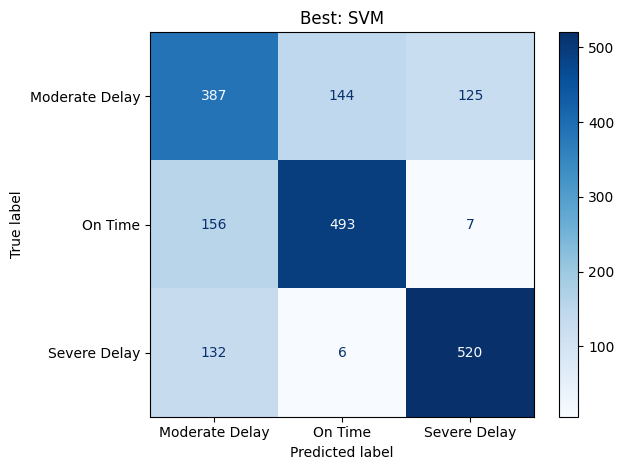

                precision    recall  f1-score   support

Moderate Delay       0.57      0.59      0.58       656
       On Time       0.77      0.75      0.76       656
  Severe Delay       0.80      0.79      0.79       658

      accuracy                           0.71      1970
     macro avg       0.71      0.71      0.71      1970
  weighted avg       0.71      0.71      0.71      1970



In [119]:
#subtask3.3
y_pred_best = best_search.predict(X_test)

print('Accuracy:', accuracy_score(y_class_test, y_pred_best))
print('Macro Precision:', precision_score(y_class_test, y_pred_best, average='macro'))
print('Macro Recall:', recall_score(y_class_test, y_pred_best, average='macro'))
print('Macro F1:', f1_score(y_class_test, y_pred_best, average='macro'))

ConfusionMatrixDisplay.from_predictions(
    y_class_test, y_pred_best, cmap=plt.cm.Blues, values_format='d',
)
plt.title(f'Best: {best_model_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_class_test, y_pred_best))

**Test Results — SVM (selected model)**

Accuracy: 0.711 | Macro F1: 0.711

**Best/worst classes:** Severe Delay (79% recall) and On Time (75%)
are handled well. Moderate Delay is weakest (59% recall) — it's the
class most often misclassified.

**Where the confusion is:** almost all errors involve Moderate Delay
blurring into its neighbors — 144 Moderate trips predicted On Time, 125
predicted Severe. The two extremes are rarely confused with each other
(only 6–7 cases each way).

**Most important error:** the 6 Severe Delay trips predicted as On Time
are the costliest — the model signals "all fine" on a trip that actually
needs intervention. Confusing Severe with Moderate is far less risky,
since Moderate still flags the trip as delayed.

In [120]:
#task4
#subtask4.1
model_search_space_reg = {
    'Linear Regression': {
        'model': LinearRegression(),
        'parameters': {
            'model__fit_intercept': [True, False],
        },
    },
    'KNN Regressor': {
        'model': KNeighborsRegressor(),
        'parameters': {
            'model__n_neighbors': [5, 9, 15],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2],
        },
    },
}

In [121]:
#suubtask4.2
def run_gridsearch_reg(X_train, y_train, preprocessor, model_search_space, random_state=42):
    from sklearn.model_selection import KFold
    cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    search_results = {}
    rows = []
    for model_name, specification in model_search_space.items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', specification['model']),
        ])
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=specification['parameters'],
            scoring='r2',
            cv=cv, n_jobs=-1,
        )
        search.fit(X_train, y_train)
        search_results[model_name] = search

        best_r2 = search.best_score_
        best_fold_std = search.cv_results_['std_test_score'][search.best_index_]

        rows.append({
            'Model': model_name,
            'Best Mean CV r2': best_r2,
            'Std Across Folds': best_fold_std,
            'Best Params': search.best_params_,
        })
    comparison_df = (pd.DataFrame(rows)
                     .sort_values('Best Mean CV r2', ascending=False)
                     .reset_index(drop=True))
    return comparison_df, search_results


In [122]:
reg_comparison, reg_search_results = run_gridsearch_reg(
    X_train, y_reg_train, preprocessor, model_search_space_reg)
pd.set_option('display.max_colwidth', None)
reg_comparison

,Model,Best Mean CV r2,Std Across Folds,Best Params
0,KNN Regressor,0.926784,0.004159,"{'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}"
1,Linear Regression,0.924093,0.002990,{'model__fit_intercept': True}


In [123]:
reg_comparison.loc[0, 'Best Params']

{'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}

In [124]:
best_reg_name = reg_comparison.loc[0, 'Model']
best_reg_r2 = reg_comparison.loc[0, 'Best Mean CV r2']
best_reg_search = reg_search_results[best_reg_name]
print(f"Selected: {best_reg_name} — CV r2: {best_reg_r2:.3f} min "
      f"(±{reg_comparison.loc[0, 'Std Across Folds']:.3f})")
print(f"Params: {best_reg_search.best_params_}")

Selected: KNN Regressor — CV r2: 0.927 min (±0.004)
Params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}


**Selection:** KNN Regressor was chosen because it had a higher
mean cross-validated r2 (0.927) than Linear Regression (0.924), using
cross-validation results only the test set was not touched during
selection.

MAE: 6.488
RMSE: 8.612
r2: 0.936


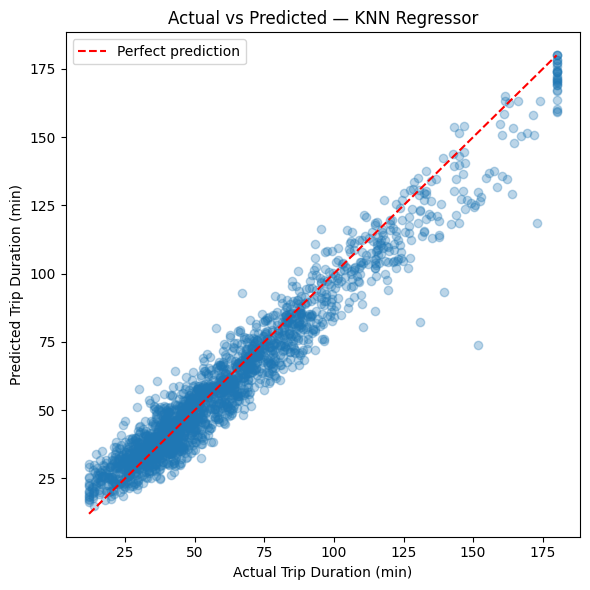

In [125]:
#subtask4.3

y_pred_reg = best_reg_search.predict(X_test)

mae = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2 = r2_score(y_reg_test, y_pred_reg)

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'r2: {r2:.3f}')

plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_pred_reg, alpha=0.3)
lims = [y_reg_test.min(), y_reg_test.max()]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Trip Duration (min)')
plt.ylabel('Predicted Trip Duration (min)')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.show()

**Test Results — KNN Regressor (selected model)**

MAE: 6.49 min | RMSE: 8.61 min | R²: 0.936

**Error size:** off by 6.5 min on average about 12% error on a typical
52-min trip, but over 30% on a short 20-min trip.

**Fit for use:**
- Schedule planning: good fit (R² = 0.94).
- Arrival estimation: usable, but riskier on short trips.
- Passenger communication: better as a range ("50-60 min") than an exact number.

**Least reliable spot:** RMSE (8.61) is noticeably higher than MAE (6.49),
meaning some predictions miss by a lot more than average. The plot shows
this near 175-180 min making the model's longest-trip predictions the least trustworthy.

In [126]:
#task5
#subtask5.1

joblib.dump(best_search.best_estimator_, 'EYOUTH-31005121300737_best_bus_delay_classifier.joblib')
joblib.dump(best_reg_search.best_estimator_, 'EYOUTH-31005121300737_best_bus_duration_regressor.joblib')


loaded_classifier = joblib.load('EYOUTH-31005121300737_best_bus_delay_classifier.joblib')
loaded_regressor = joblib.load('EYOUTH-31005121300737_best_bus_duration_regressor.joblib')

print('Classifier reload check:', loaded_classifier.predict(X_test.head()))
print('Regressor reload check:', loaded_regressor.predict(X_test.head()))

Classifier reload check: ['On Time' 'Moderate Delay' 'Moderate Delay' 'On Time' 'On Time']
Regressor reload check: [29.83354201 42.32371252 41.65440845 54.88494363 36.33814701]


In [127]:
#subtask5.2
new_trips = pd.read_csv('New_Bus_Trips.csv')




predictions = pd.DataFrame({
    'trip_id': new_trips['trip_id'],
    'predicted_delay_level': loaded_classifier.predict(new_trips),
    'predicted_trip_duration_minutes': loaded_regressor.predict(new_trips),
})
predictions

,trip_id,predicted_delay_level,predicted_trip_duration_minutes
0,NEW001,On Time,19.163966
1,NEW002,Severe Delay,100.750380
2,NEW003,Severe Delay,171.375926
3,NEW004,On Time,45.836484
4,NEW005,Severe Delay,67.998976
5,NEW006,Severe Delay,165.380225
6,NEW007,On Time,19.907289
7,NEW008,Moderate Delay,85.756454
8,NEW009,Severe Delay,62.508440
9,NEW010,Severe Delay,163.384532


In [128]:
#subtask5.3 is the report